In [2]:
# bootstrap local project files into the Colab runtime
import base64, os, pathlib, sys, subprocess
PROJECT_ROOT = pathlib.Path('/content/cs4782_project')
CODE_DIR = PROJECT_ROOT / 'code'
RESULTS_DIR = PROJECT_ROOT / 'results'
CODE_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(parents=True, exist_ok=True)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'transformers', 'nltk', 'rouge-score', 'matplotlib', 'tqdm'])
PROJECT_FILES = {
    'lora.py': 'aW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubiBhcyBubgppbXBvcnQgbWF0aAoKCmNsYXNzIExvUkFMaW5lYXIobm4uTW9kdWxlKToKICAgICIiIkxvdy1yYW5rIGFkYXB0YXRpb24gd3JhcHBlciBmb3IgYSBmcm96ZW4gbGluZWFyIGxheWVyLgoKICAgIEFkZHMgdHJhaW5hYmxlIG1hdHJpY2VzIEEgKHJhbmsgeCBkX2luKSBhbmQgQiAoZF9vdXQgeCByYW5rKSBzdWNoIHRoYXQ6CiAgICAgICAgb3V0cHV0ID0gZnJvemVuX2xpbmVhcih4KSArICh4IEAgQV5UIEAgQl5UKSAqIChhbHBoYSAvIHJhbmspCgogICAgQiBpcyBpbml0aWFsaXplZCB0byB6ZXJvcyBzbyB0aGUgTG9SQSBjb250cmlidXRpb24gc3RhcnRzIGF0IHplcm8uCiAgICAiIiIKCiAgICBkZWYgX19pbml0X18oc2VsZiwgb3JpZ2luYWxfbGF5ZXIsIHJhbmssIGFscGhhKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBzZWxmLm9yaWdpbmFsX2xheWVyID0gb3JpZ2luYWxfbGF5ZXIKCiAgICAgICAgIyBmcmVlemUgb3JpZ2luYWwgd2VpZ2h0cyBzbyBncmFkaWVudHMgZG9udCBmbG93IGJhY2sKICAgICAgICBmb3IgcGFyYW0gaW4gc2VsZi5vcmlnaW5hbF9sYXllci5wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgIHBhcmFtLnJlcXVpcmVzX2dyYWQgPSBGYWxzZQoKICAgICAgICAjIHRvb2sgZm9yZXZlciB0byBmaWd1cmUgb3V0IGdwdDIgdXNlcyBDb252MUQgbm90IExpbmVhciBsb2wKICAgICAgICAjIENvbnYxRCBzdG9yZXMgd2VpZ2h0cyBhcyAoZF9pbiwgZF9vdXQpIGluc3RlYWQgb2YgKGRfb3V0LCBkX2luKQogICAgICAgIGlmIGhhc2F0dHIob3JpZ2luYWxfbGF5ZXIsICduZicpOgogICAgICAgICAgICAjIGh1Z2dpbmdmYWNlIENvbnYxRDogd2VpZ2h0IGlzIChkX2luLCBkX291dCksIG5mID0gZF9vdXQKICAgICAgICAgICAgc2VsZi5kX2luID0gb3JpZ2luYWxfbGF5ZXIud2VpZ2h0LnNoYXBlWzBdCiAgICAgICAgICAgIHNlbGYuZF9vdXQgPSBvcmlnaW5hbF9sYXllci5uZgogICAgICAgICAgICBzZWxmLmlzX2NvbnYxZCA9IFRydWUKICAgICAgICBlbHNlOgogICAgICAgICAgICAjIHJlZ3VsYXIgbm4uTGluZWFyOiB3ZWlnaHQgaXMgKGRfb3V0LCBkX2luKQogICAgICAgICAgICBzZWxmLmRfaW4gPSBvcmlnaW5hbF9sYXllci5pbl9mZWF0dXJlcwogICAgICAgICAgICBzZWxmLmRfb3V0ID0gb3JpZ2luYWxfbGF5ZXIub3V0X2ZlYXR1cmVzCiAgICAgICAgICAgIHNlbGYuaXNfY29udjFkID0gRmFsc2UKCiAgICAgICAgc2VsZi5yYW5rID0gcmFuawogICAgICAgIHNlbGYuYWxwaGEgPSBhbHBoYQogICAgICAgIHNlbGYuc2NhbGluZyA9IGFscGhhIC8gcmFuawoKICAgICAgICAjIEEgZ2V0cyBrYWltaW5nIGluaXQsIEIgZ2V0cyB6ZXJvcwogICAgICAgICMgdGhpcyB3YXkgdGhlIGxvcmEgY29udHJpYnV0aW9uIHN0YXJ0cyBhdCAwIGFuZCBkb2VzbnQgbWVzcyB1cCB0aGUgcHJldHJhaW5lZCB3ZWlnaHRzCiAgICAgICAgc2VsZi5sb3JhX0EgPSBubi5QYXJhbWV0ZXIodG9yY2guZW1wdHkocmFuaywgc2VsZi5kX2luKSkKICAgICAgICBubi5pbml0LmthaW1pbmdfdW5pZm9ybV8oc2VsZi5sb3JhX0EsIGE9bWF0aC5zcXJ0KDUpKQoKICAgICAgICBzZWxmLmxvcmFfQiA9IG5uLlBhcmFtZXRlcih0b3JjaC56ZXJvcyhzZWxmLmRfb3V0LCByYW5rKSkKCiAgICBkZWYgZm9yd2FyZChzZWxmLCB4KToKICAgICAgICAjIG9yaWdpbmFsIGZyb3plbiBvdXRwdXQgKyBsb3cgcmFuayB1cGRhdGUKICAgICAgICBvcmlnaW5hbF9vdXRwdXQgPSBzZWxmLm9yaWdpbmFsX2xheWVyKHgpCiAgICAgICAgIyB4IEAgQV5UIGdpdmVzIChiYXRjaCwgc2VxLCByYW5rKSwgdGhlbiBAIEJeVCBnaXZlcyAoYmF0Y2gsIHNlcSwgZF9vdXQpCiAgICAgICAgbG9yYV9vdXRwdXQgPSB4IEAgc2VsZi5sb3JhX0EuVCBAIHNlbGYubG9yYV9CLlQgKiBzZWxmLnNjYWxpbmcKICAgICAgICByZXR1cm4gb3JpZ2luYWxfb3V0cHV0ICsgbG9yYV9vdXRwdXQKCgpjbGFzcyBMb1JBUVZXcmFwcGVyKG5uLk1vZHVsZSk6CiAgICAiIiJXcmFwcyBHUFQtMidzIGZ1c2VkIGNfYXR0biAoQ29udjFEKSBhbmQgYXBwbGllcyBMb1JBIHRvIFEgYW5kIFYgc2xpY2VzIG9ubHkuCgogICAgR1BULTIncyBjX2F0dG4gcHJvamVjdHMgKDc2OCAtPiAyMzA0KSwgd2hlcmUgb3V0cHV0IGlzIFtRfEt8Vl0gZWFjaCBvZiBkaW0gNzY4LgogICAgV2Ugb25seSBhZGQgTG9SQSB0byBRIGFuZCBWLCBub3QgSyAoZm9sbG93aW5nIHRoZSBwYXBlcikuCiAgICAiIiIKCiAgICAjIHRoaXMgd2FzIHBhaW4gdG8gZGVidWcgYmMgY19hdHRuIGlzIGEgc2luZ2xlIGxheWVyIHRoYXQgb3V0cHV0cyBRIEsgViBjb25jYXRlbmF0ZWQKICAgICMgc28gd2UgY2FudCBqdXN0IHdyYXAgaXQgd2l0aCBMb1JBTGluZWFyIGRpcmVjdGx5LCB3ZSBuZWVkIHRvIHNwbGl0IHRoZSBvdXRwdXQKICAgICMgYW5kIGFkZCBsb3JhIHRvIGp1c3QgdGhlIFEgYW5kIFYgcGFydHMKCiAgICBkZWYgX19pbml0X18oc2VsZiwgb3JpZ2luYWxfY19hdHRuLCByYW5rLCBhbHBoYSk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5vcmlnaW5hbF9jX2F0dG4gPSBvcmlnaW5hbF9jX2F0dG4KCiAgICAgICAgZm9yIHBhcmFtIGluIHNlbGYub3JpZ2luYWxfY19hdHRuLnBhcmFtZXRlcnMoKToKICAgICAgICAgICAgcGFyYW0ucmVxdWlyZXNfZ3JhZCA9IEZhbHNlCgogICAgICAgIGRfaW4gPSBvcmlnaW5hbF9jX2F0dG4ud2VpZ2h0LnNoYXBlWzBdICAgIyA3NjgKICAgICAgICBkX2hlYWQgPSBvcmlnaW5hbF9jX2F0dG4ubmYgLy8gMyAgICAgICAgICAjIDc2OCAoZWFjaCBvZiBRLCBLLCBWKQoKICAgICAgICBzZWxmLnNjYWxpbmcgPSBhbHBoYSAvIHJhbmsKCiAgICAgICAgIyBzZXBhcmF0ZSBsb3JhIG1hdHJpY2VzIGZvciBRIGFuZCBWCiAgICAgICAgc2VsZi5sb3JhX3FfQSA9IG5uLlBhcmFtZXRlcih0b3JjaC5lbXB0eShyYW5rLCBkX2luKSkKICAgICAgICBubi5pbml0LmthaW1pbmdfdW5pZm9ybV8oc2VsZi5sb3JhX3FfQSwgYT1tYXRoLnNxcnQoNSkpCiAgICAgICAgc2VsZi5sb3JhX3FfQiA9IG5uLlBhcmFtZXRlcih0b3JjaC56ZXJvcyhkX2hlYWQsIHJhbmspKQoKICAgICAgICBzZWxmLmxvcmFfdl9BID0gbm4uUGFyYW1ldGVyKHRvcmNoLmVtcHR5KHJhbmssIGRfaW4pKQogICAgICAgIG5uLmluaXQua2FpbWluZ191bmlmb3JtXyhzZWxmLmxvcmFfdl9BLCBhPW1hdGguc3FydCg1KSkKICAgICAgICBzZWxmLmxvcmFfdl9CID0gbm4uUGFyYW1ldGVyKHRvcmNoLnplcm9zKGRfaGVhZCwgcmFuaykpCgogICAgZGVmIGZvcndhcmQoc2VsZiwgeCk6CiAgICAgICAgIyBnZXQgdGhlIG9yaWdpbmFsIFtRfEt8Vl0gb3V0cHV0CiAgICAgICAgcWt2ID0gc2VsZi5vcmlnaW5hbF9jX2F0dG4oeCkKICAgICAgICBkX2hlYWQgPSBxa3Yuc2hhcGVbLTFdIC8vIDMKCiAgICAgICAgIyBjb21wdXRlIGxvcmEgdXBkYXRlcyBmb3IgUSBhbmQgViBvbmx5CiAgICAgICAgbG9yYV9xID0gKHggQCBzZWxmLmxvcmFfcV9BLlQgQCBzZWxmLmxvcmFfcV9CLlQpICogc2VsZi5zY2FsaW5nCiAgICAgICAgbG9yYV92ID0gKHggQCBzZWxmLmxvcmFfdl9BLlQgQCBzZWxmLmxvcmFfdl9CLlQpICogc2VsZi5zY2FsaW5nCgogICAgICAgICMgYWRkIGxvcmEgdG8gdGhlIFEgYW5kIFYgc2xpY2VzCiAgICAgICAgIyB0aGlzIGRpZG50IHdvcmsgd2l0aG91dCBjbG9uZSgpIGJlY2F1c2Ugb2YgaW4tcGxhY2UgbW9kaWZpY2F0aW9uIGlzc3VlcwogICAgICAgIHFrdiA9IHFrdi5jbG9uZSgpCiAgICAgICAgcWt2WzosIDosIDpkX2hlYWRdICs9IGxvcmFfcSAgICAgICAgICAgIyBRIHNsaWNlCiAgICAgICAgcWt2WzosIDosIDIgKiBkX2hlYWQ6XSArPSBsb3JhX3YgICAgICAgIyBWIHNsaWNlIChLIGlzIGluIHRoZSBtaWRkbGUsIHVudG91Y2hlZCkKCiAgICAgICAgcmV0dXJuIHFrdgoKCmRlZiBpbmplY3RfbG9yYShtb2RlbCwgcmFuaywgYWxwaGEsIHRhcmdldF9tb2R1bGVzPU5vbmUpOgogICAgIiIiSW5qZWN0IExvUkEgaW50byBHUFQtMidzIGF0dGVudGlvbiBsYXllcnMuCgogICAgRnJlZXplcyBldmVyeXRoaW5nLCB0aGVuIHJlcGxhY2VzIGNfYXR0biB3aXRoIExvUkFRVldyYXBwZXIKICAgIHNvIG9ubHkgdGhlIGxvdy1yYW5rIG1hdHJpY2VzIGFyZSB0cmFpbmFibGUuCiAgICAiIiIKICAgIGlmIHRhcmdldF9tb2R1bGVzIGlzIE5vbmU6CiAgICAgICAgdGFyZ2V0X21vZHVsZXMgPSBbImF0dG4uY19hdHRuIl0KCiAgICAjIGZyZWV6ZSBldmVyeXRoaW5nIGZpcnN0CiAgICBmb3IgcGFyYW0gaW4gbW9kZWwucGFyYW1ldGVycygpOgogICAgICAgIHBhcmFtLnJlcXVpcmVzX2dyYWQgPSBGYWxzZQoKICAgICMgY29sbGVjdCBtb2R1bGVzIHRvIHJlcGxhY2UgLSBjYW50IG1vZGlmeSBkaWN0IHdoaWxlIGl0ZXJhdGluZwogICAgIyAobGVhcm5lZCB0aGlzIHRoZSBoYXJkIHdheSBsb2wpCiAgICByZXBsYWNlbWVudHMgPSBbXQogICAgZm9yIG5hbWUsIG1vZHVsZSBpbiBtb2RlbC5uYW1lZF9tb2R1bGVzKCk6CiAgICAgICAgaWYgYW55KG5hbWUuZW5kc3dpdGgodGFyZ2V0KSBmb3IgdGFyZ2V0IGluIHRhcmdldF9tb2R1bGVzKToKICAgICAgICAgICAgcmVwbGFjZW1lbnRzLmFwcGVuZCgobmFtZSwgbW9kdWxlKSkKCiAgICBmb3IgbmFtZSwgbW9kdWxlIGluIHJlcGxhY2VtZW50czoKICAgICAgICAjIHdhbGsgZG93biB0aGUgbW9kdWxlIHRyZWUgdG8gZmluZCB0aGUgcGFyZW50CiAgICAgICAgcGFydHMgPSBuYW1lLnNwbGl0KCIuIikKICAgICAgICBwYXJlbnQgPSBtb2RlbAogICAgICAgIGZvciBwYXJ0IGluIHBhcnRzWzotMV06CiAgICAgICAgICAgIHBhcmVudCA9IGdldGF0dHIocGFyZW50LCBwYXJ0KQogICAgICAgIGF0dHJfbmFtZSA9IHBhcnRzWy0xXQoKICAgICAgICAjIHVzZSBRViB3cmFwcGVyIGZvciBjX2F0dG4sIHJlZ3VsYXIgTG9SQUxpbmVhciBmb3IgZXZlcnl0aGluZyBlbHNlCiAgICAgICAgaWYgbmFtZS5lbmRzd2l0aCgiY19hdHRuIik6CiAgICAgICAgICAgIHdyYXBwZXIgPSBMb1JBUVZXcmFwcGVyKG1vZHVsZSwgcmFuaywgYWxwaGEpCiAgICAgICAgZWxzZToKICAgICAgICAgICAgd3JhcHBlciA9IExvUkFMaW5lYXIobW9kdWxlLCByYW5rLCBhbHBoYSkKCiAgICAgICAgc2V0YXR0cihwYXJlbnQsIGF0dHJfbmFtZSwgd3JhcHBlcikKCgpkZWYgbWVyZ2VfbG9yYShtb2RlbCk6CiAgICAiIiJGb2xkIExvUkEgd2VpZ2h0cyBiYWNrIGludG8gdGhlIG9yaWdpbmFsIGxheWVycyBhbmQgcmVtb3ZlIHdyYXBwZXJzLgoKICAgIEFmdGVyIG1lcmdpbmcgdGhlIG1vZGVsIHByb2R1Y2VzIGlkZW50aWNhbCBvdXRwdXQgYnV0IHdpdGhvdXQgYW55IExvUkEKICAgIG1vZHVsZXMsIHNvIHRoZXJlcyBubyBleHRyYSBpbmZlcmVuY2UgY29zdC4KICAgICIiIgogICAgIyBUT0RPOiBtYXliZSBhZGQgb3B0aW9uIHRvIGtlZXAgd3JhcHBlcnMgYXJvdW5kIGZvciBmdXJ0aGVyIHRyYWluaW5nPwogICAgcmVwbGFjZW1lbnRzID0gW10KICAgIGZvciBuYW1lLCBtb2R1bGUgaW4gbW9kZWwubmFtZWRfbW9kdWxlcygpOgogICAgICAgIGlmIGlzaW5zdGFuY2UobW9kdWxlLCAoTG9SQVFWV3JhcHBlciwgTG9SQUxpbmVhcikpOgogICAgICAgICAgICByZXBsYWNlbWVudHMuYXBwZW5kKChuYW1lLCBtb2R1bGUpKQoKICAgIGZvciBuYW1lLCBtb2R1bGUgaW4gcmVwbGFjZW1lbnRzOgogICAgICAgIHBhcnRzID0gbmFtZS5zcGxpdCgiLiIpCiAgICAgICAgcGFyZW50ID0gbW9kZWwKICAgICAgICBmb3IgcGFydCBpbiBwYXJ0c1s6LTFdOgogICAgICAgICAgICBwYXJlbnQgPSBnZXRhdHRyKHBhcmVudCwgcGFydCkKICAgICAgICBhdHRyX25hbWUgPSBwYXJ0c1stMV0KCiAgICAgICAgaWYgaXNpbnN0YW5jZShtb2R1bGUsIExvUkFRVldyYXBwZXIpOgogICAgICAgICAgICBjX2F0dG4gPSBtb2R1bGUub3JpZ2luYWxfY19hdHRuCiAgICAgICAgICAgIGRfaGVhZCA9IGNfYXR0bi5uZiAvLyAzCgogICAgICAgICAgICB3aXRoIHRvcmNoLm5vX2dyYWQoKToKICAgICAgICAgICAgICAgICMgbWVyZ2UgUSBsb3JhOiBkZWx0YV9XID0gQiBAIEEsIHNoYXBlIChkX2hlYWQsIGRfaW4pCiAgICAgICAgICAgICAgICBkZWx0YV9xID0gKG1vZHVsZS5sb3JhX3FfQiBAIG1vZHVsZS5sb3JhX3FfQSkgKiBtb2R1bGUuc2NhbGluZwogICAgICAgICAgICAgICAgIyBDb252MUQgd2VpZ2h0IGlzIChkX2luLCBkX291dCksIHNvIHdlIHRyYW5zcG9zZSBhbmQgYWRkIHRvIFEgY29sdW1ucwogICAgICAgICAgICAgICAgY19hdHRuLndlaWdodFs6LCA6ZF9oZWFkXSArPSBkZWx0YV9xLlQKCiAgICAgICAgICAgICAgICAjIHNhbWUgdGhpbmcgZm9yIFYKICAgICAgICAgICAgICAgIGRlbHRhX3YgPSAobW9kdWxlLmxvcmFfdl9CIEAgbW9kdWxlLmxvcmFfdl9BKSAqIG1vZHVsZS5zY2FsaW5nCiAgICAgICAgICAgICAgICBjX2F0dG4ud2VpZ2h0WzosIDIgKiBkX2hlYWQ6XSArPSBkZWx0YV92LlQKCiAgICAgICAgICAgIHNldGF0dHIocGFyZW50LCBhdHRyX25hbWUsIGNfYXR0bikKCiAgICAgICAgZWxpZiBpc2luc3RhbmNlKG1vZHVsZSwgTG9SQUxpbmVhcik6CiAgICAgICAgICAgIG9yaWdpbmFsID0gbW9kdWxlLm9yaWdpbmFsX2xheWVyCiAgICAgICAgICAgIHdpdGggdG9yY2gubm9fZ3JhZCgpOgogICAgICAgICAgICAgICAgZGVsdGEgPSAobW9kdWxlLmxvcmFfQiBAIG1vZHVsZS5sb3JhX0EpICogbW9kdWxlLnNjYWxpbmcKICAgICAgICAgICAgICAgIGlmIG1vZHVsZS5pc19jb252MWQ6CiAgICAgICAgICAgICAgICAgICAgIyBjb252MWQgd2VpZ2h0IGlzIHRyYW5zcG9zZWQgY29tcGFyZWQgdG8gbGluZWFyCiAgICAgICAgICAgICAgICAgICAgb3JpZ2luYWwud2VpZ2h0ICs9IGRlbHRhLlQKICAgICAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICAgICAgb3JpZ2luYWwud2VpZ2h0ICs9IGRlbHRhCgogICAgICAgICAgICBzZXRhdHRyKHBhcmVudCwgYXR0cl9uYW1lLCBvcmlnaW5hbCkK',
    'data.py': 'aW1wb3J0IHRvcmNoCmZyb20gdG9yY2gudXRpbHMuZGF0YSBpbXBvcnQgRGF0YXNldCwgRGF0YUxvYWRlcgpmcm9tIHRyYW5zZm9ybWVycyBpbXBvcnQgR1BUMlRva2VuaXplcgppbXBvcnQgY3N2CmltcG9ydCBzc2wKZnJvbSB1cmxsaWIuZXJyb3IgaW1wb3J0IFVSTEVycm9yCmltcG9ydCB1cmxsaWIucmVxdWVzdAoKClNQRUNJQUxfVE9LRU5TID0geyJtcl90b2tlbiI6ICI8TVI+IiwgInRleHRfdG9rZW4iOiAiPFRFWFQ+In0KRTJFX0JBU0VfVVJMID0gImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS90dWV0c2NoZWsvZTJlLWRhdGFzZXQvbWFzdGVyLyIKRTJFX0ZJTEVTID0gewogICAgInRyYWluIjogInRyYWluc2V0LmNzdiIsCiAgICAidmFsaWRhdGlvbiI6ICJkZXZzZXQuY3N2IiwKICAgICJ0ZXN0IjogInRlc3RzZXRfd19yZWZzLmNzdiIsCn0KCgpkZWYgbG9hZF9lMmVfZGF0YXNldCgpOgogICAgIiIiTG9hZCBFMkUgTkxHIGRpcmVjdGx5IGZyb20gdGhlIG9mZmljaWFsIENTViBmaWxlcy4iIiIKICAgIGRhdGFzZXQgPSB7fQoKICAgIGZvciBzcGxpdCwgZmlsZW5hbWUgaW4gRTJFX0ZJTEVTLml0ZW1zKCk6CiAgICAgICAgdXJsID0gRTJFX0JBU0VfVVJMICsgZmlsZW5hbWUKICAgICAgICB0cnk6CiAgICAgICAgICAgIHdpdGggdXJsbGliLnJlcXVlc3QudXJsb3Blbih1cmwpIGFzIHJlc3BvbnNlOgogICAgICAgICAgICAgICAgdGV4dCA9IHJlc3BvbnNlLnJlYWQoKS5kZWNvZGUoInV0Zi04IikKICAgICAgICBleGNlcHQgVVJMRXJyb3IgYXMgZXhjOgogICAgICAgICAgICBpZiBub3QgaXNpbnN0YW5jZShleGMucmVhc29uLCBzc2wuU1NMQ2VydFZlcmlmaWNhdGlvbkVycm9yKToKICAgICAgICAgICAgICAgIHJhaXNlCiAgICAgICAgICAgIGNvbnRleHQgPSBzc2wuX2NyZWF0ZV91bnZlcmlmaWVkX2NvbnRleHQoKQogICAgICAgICAgICB3aXRoIHVybGxpYi5yZXF1ZXN0LnVybG9wZW4odXJsLCBjb250ZXh0PWNvbnRleHQpIGFzIHJlc3BvbnNlOgogICAgICAgICAgICAgICAgdGV4dCA9IHJlc3BvbnNlLnJlYWQoKS5kZWNvZGUoInV0Zi04IikKCiAgICAgICAgcm93cyA9IFtdCiAgICAgICAgcmVhZGVyID0gY3N2LkRpY3RSZWFkZXIodGV4dC5zcGxpdGxpbmVzKCkpCiAgICAgICAgZm9yIHJvdyBpbiByZWFkZXI6CiAgICAgICAgICAgIHJvd3MuYXBwZW5kKHsKICAgICAgICAgICAgICAgICJtZWFuaW5nX3JlcHJlc2VudGF0aW9uIjogcm93WyJtciJdLAogICAgICAgICAgICAgICAgImh1bWFuX3JlZmVyZW5jZSI6IHJvd1sicmVmIl0sCiAgICAgICAgICAgIH0pCiAgICAgICAgZGF0YXNldFtzcGxpdF0gPSByb3dzCgogICAgcmV0dXJuIGRhdGFzZXQKCgpkZWYgZ2V0X3Rva2VuaXplcigpOgogICAgIiIiTG9hZCBHUFQtMiB0b2tlbml6ZXIgd2l0aCBzcGVjaWFsIHRva2VucyBmb3IgRTJFIHRhc2suIiIiCiAgICB0b2tlbml6ZXIgPSBHUFQyVG9rZW5pemVyLmZyb21fcHJldHJhaW5lZCgiZ3B0MiIpCiAgICAjIGdwdDIgZG9lc250IGhhdmUgYSBwYWQgdG9rZW4gYnkgZGVmYXVsdCBzbyB3ZSB1c2UgZW9zCiAgICB0b2tlbml6ZXIucGFkX3Rva2VuID0gdG9rZW5pemVyLmVvc190b2tlbgogICAgdG9rZW5pemVyLmFkZF9zcGVjaWFsX3Rva2Vucyh7CiAgICAgICAgImFkZGl0aW9uYWxfc3BlY2lhbF90b2tlbnMiOiBbU1BFQ0lBTF9UT0tFTlNbIm1yX3Rva2VuIl0sIFNQRUNJQUxfVE9LRU5TWyJ0ZXh0X3Rva2VuIl1dCiAgICB9KQogICAgcmV0dXJuIHRva2VuaXplcgoKCmNsYXNzIEUyRURhdGFzZXQoRGF0YXNldCk6CiAgICAiIiJFMkUgTkxHIGRhdGFzZXQgZm9ybWF0dGVkIGZvciBHUFQtMiBhdXRvcmVncmVzc2l2ZSB0cmFpbmluZy4KCiAgICBFYWNoIGV4YW1wbGUgaXMgZm9ybWF0dGVkIGFzOgogICAgICAgIDxNUj4gbWVhbmluZ19yZXByZXNlbnRhdGlvbiA8VEVYVD4gcmVmZXJlbmNlX3RleHQgPHxlbmRvZnRleHR8PgogICAgIiIiCgogICAgZGVmIF9faW5pdF9fKHNlbGYsIGhmX2RhdGFzZXQsIHRva2VuaXplciwgbWF4X2xlbmd0aD0yNTYpOgogICAgICAgIHNlbGYudG9rZW5pemVyID0gdG9rZW5pemVyCiAgICAgICAgc2VsZi5tYXhfbGVuZ3RoID0gbWF4X2xlbmd0aAogICAgICAgIHNlbGYuZXhhbXBsZXMgPSBbXQoKICAgICAgICBtcl90b2tlbiA9IFNQRUNJQUxfVE9LRU5TWyJtcl90b2tlbiJdCiAgICAgICAgdGV4dF90b2tlbiA9IFNQRUNJQUxfVE9LRU5TWyJ0ZXh0X3Rva2VuIl0KCiAgICAgICAgIyBmb3JtYXQgZWFjaCBleGFtcGxlIGFzIGEgc2luZ2xlIHN0cmluZyBmb3IgYXV0b3JlZ3Jlc3NpdmUgdHJhaW5pbmcKICAgICAgICBmb3IgaXRlbSBpbiBoZl9kYXRhc2V0OgogICAgICAgICAgICBwcm9tcHQgPSBmInttcl90b2tlbn0ge2l0ZW1bJ21lYW5pbmdfcmVwcmVzZW50YXRpb24nXX0ge3RleHRfdG9rZW59IHtpdGVtWydodW1hbl9yZWZlcmVuY2UnXX17dG9rZW5pemVyLmVvc190b2tlbn0iCiAgICAgICAgICAgIGVuY29kZWQgPSB0b2tlbml6ZXIoCiAgICAgICAgICAgICAgICBwcm9tcHQsCiAgICAgICAgICAgICAgICB0cnVuY2F0aW9uPVRydWUsCiAgICAgICAgICAgICAgICBtYXhfbGVuZ3RoPW1heF9sZW5ndGgsCiAgICAgICAgICAgICAgICByZXR1cm5fdGVuc29ycz1Ob25lLAogICAgICAgICAgICApCiAgICAgICAgICAgIHNlbGYuZXhhbXBsZXMuYXBwZW5kKHsKICAgICAgICAgICAgICAgICJpbnB1dF9pZHMiOiBlbmNvZGVkWyJpbnB1dF9pZHMiXSwKICAgICAgICAgICAgICAgICJhdHRlbnRpb25fbWFzayI6IGVuY29kZWRbImF0dGVudGlvbl9tYXNrIl0sCiAgICAgICAgICAgIH0pCgogICAgZGVmIF9fbGVuX18oc2VsZik6CiAgICAgICAgcmV0dXJuIGxlbihzZWxmLmV4YW1wbGVzKQoKICAgIGRlZiBfX2dldGl0ZW1fXyhzZWxmLCBpZHgpOgogICAgICAgIHJldHVybiBzZWxmLmV4YW1wbGVzW2lkeF0KCgpkZWYgY29sbGF0ZV9mbihiYXRjaCwgcGFkX3Rva2VuX2lkKToKICAgICIiIlBhZCBzZXF1ZW5jZXMgdG8gdGhlIGxvbmdlc3QgaW4gdGhlIGJhdGNoLiIiIgogICAgbWF4X2xlbiA9IG1heChsZW4oaXRlbVsiaW5wdXRfaWRzIl0pIGZvciBpdGVtIGluIGJhdGNoKQoKICAgIGlucHV0X2lkcyA9IFtdCiAgICBhdHRlbnRpb25fbWFzayA9IFtdCiAgICBsYWJlbHMgPSBbXQoKICAgIGZvciBpdGVtIGluIGJhdGNoOgogICAgICAgIGlkcyA9IGl0ZW1bImlucHV0X2lkcyJdCiAgICAgICAgbWFzayA9IGl0ZW1bImF0dGVudGlvbl9tYXNrIl0KICAgICAgICBwYWRkaW5nX2xlbmd0aCA9IG1heF9sZW4gLSBsZW4oaWRzKQoKICAgICAgICBpbnB1dF9pZHMuYXBwZW5kKGlkcyArIFtwYWRfdG9rZW5faWRdICogcGFkZGluZ19sZW5ndGgpCiAgICAgICAgYXR0ZW50aW9uX21hc2suYXBwZW5kKG1hc2sgKyBbMF0gKiBwYWRkaW5nX2xlbmd0aCkKICAgICAgICAjIGxhYmVscyBhcmUgc2FtZSBhcyBpbnB1dF9pZHMgYnV0IC0xMDAgZm9yIHBhZGRpbmcgc28gbG9zcyBpZ25vcmVzIHRoZW0KICAgICAgICAjIHRvb2sgdXMgYSB3aGlsZSB0byBmaWd1cmUgb3V0IHRoZSAtMTAwIHRoaW5nIGxvbAogICAgICAgIGxhYmVsID0gaWRzICsgWy0xMDBdICogcGFkZGluZ19sZW5ndGgKICAgICAgICBsYWJlbHMuYXBwZW5kKGxhYmVsKQoKICAgIHJldHVybiB7CiAgICAgICAgImlucHV0X2lkcyI6IHRvcmNoLnRlbnNvcihpbnB1dF9pZHMsIGR0eXBlPXRvcmNoLmxvbmcpLAogICAgICAgICJhdHRlbnRpb25fbWFzayI6IHRvcmNoLnRlbnNvcihhdHRlbnRpb25fbWFzaywgZHR5cGU9dG9yY2gubG9uZyksCiAgICAgICAgImxhYmVscyI6IHRvcmNoLnRlbnNvcihsYWJlbHMsIGR0eXBlPXRvcmNoLmxvbmcpLAogICAgfQoKCmRlZiBnZXRfZGF0YWxvYWRlcnMoYmF0Y2hfc2l6ZT04LCBtYXhfbGVuZ3RoPTI1Nik6CiAgICAiIiJMb2FkIEUyRSBOTEcgZGF0YXNldCBhbmQgcmV0dXJuIHRyYWluL3ZhbC90ZXN0IERhdGFMb2FkZXJzLiIiIgogICAgZnJvbSBmdW5jdG9vbHMgaW1wb3J0IHBhcnRpYWwKCiAgICBkYXRhc2V0ID0gbG9hZF9lMmVfZGF0YXNldCgpCiAgICB0b2tlbml6ZXIgPSBnZXRfdG9rZW5pemVyKCkKICAgIHBhZF9pZCA9IHRva2VuaXplci5wYWRfdG9rZW5faWQKCiAgICB0cmFpbl9kcyA9IEUyRURhdGFzZXQoZGF0YXNldFsidHJhaW4iXSwgdG9rZW5pemVyLCBtYXhfbGVuZ3RoKQogICAgdmFsX2RzID0gRTJFRGF0YXNldChkYXRhc2V0WyJ2YWxpZGF0aW9uIl0sIHRva2VuaXplciwgbWF4X2xlbmd0aCkKICAgIHRlc3RfZHMgPSBFMkVEYXRhc2V0KGRhdGFzZXRbInRlc3QiXSwgdG9rZW5pemVyLCBtYXhfbGVuZ3RoKQoKICAgIGNvbGxhdGUgPSBwYXJ0aWFsKGNvbGxhdGVfZm4sIHBhZF90b2tlbl9pZD1wYWRfaWQpCgogICAgdHJhaW5fbG9hZGVyID0gRGF0YUxvYWRlcih0cmFpbl9kcywgYmF0Y2hfc2l6ZT1iYXRjaF9zaXplLCBzaHVmZmxlPVRydWUsIGNvbGxhdGVfZm49Y29sbGF0ZSkKICAgIHZhbF9sb2FkZXIgPSBEYXRhTG9hZGVyKHZhbF9kcywgYmF0Y2hfc2l6ZT1iYXRjaF9zaXplLCBzaHVmZmxlPUZhbHNlLCBjb2xsYXRlX2ZuPWNvbGxhdGUpCiAgICB0ZXN0X2xvYWRlciA9IERhdGFMb2FkZXIodGVzdF9kcywgYmF0Y2hfc2l6ZT1iYXRjaF9zaXplLCBzaHVmZmxlPUZhbHNlLCBjb2xsYXRlX2ZuPWNvbGxhdGUpCgogICAgcmV0dXJuIHRyYWluX2xvYWRlciwgdmFsX2xvYWRlciwgdGVzdF9sb2FkZXIsIHRva2VuaXplcgo=',
    'train.py': 'aW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubiBhcyBubgpmcm9tIHRvcmNoLm9wdGltIGltcG9ydCBBZGFtVwpmcm9tIHRvcmNoLm9wdGltLmxyX3NjaGVkdWxlciBpbXBvcnQgTGluZWFyTFIKaW1wb3J0IG5sdGsKZnJvbSByb3VnZV9zY29yZSBpbXBvcnQgcm91Z2Vfc2NvcmVyCmZyb20gdXRpbHMgaW1wb3J0IFRyYWluaW5nTG9nZ2VyLCBzYXZlX2NoZWNrcG9pbnQsIGNvdW50X3BhcmFtZXRlcnMsIHNhdmVfbWV0cmljcwoKdHJ5OgogICAgZnJvbSB0cWRtLmF1dG8gaW1wb3J0IHRxZG0KZXhjZXB0IEltcG9ydEVycm9yOgogICAgdHFkbSA9IE5vbmUKCgpkZWYgX3Byb2dyZXNzKGl0ZXJhYmxlLCAqKmt3YXJncyk6CiAgICBpZiB0cWRtIGlzIE5vbmU6CiAgICAgICAgcmV0dXJuIGl0ZXJhYmxlCiAgICByZXR1cm4gdHFkbShpdGVyYWJsZSwgKiprd2FyZ3MpCgoKZGVmIHRyYWluX29uZV9lcG9jaChtb2RlbCwgZGF0YWxvYWRlciwgb3B0aW1pemVyLCBzY2hlZHVsZXIsIGRldmljZSwgZXBvY2g9Tm9uZSwgbnVtX2Vwb2Nocz1Ob25lKToKICAgICIiIlRyYWluIGZvciBvbmUgZXBvY2guIFJldHVybnMgYXZlcmFnZSBsb3NzLiIiIgogICAgbW9kZWwudHJhaW4oKQogICAgdG90YWxfbG9zcyA9IDAKICAgIG51bV9iYXRjaGVzID0gMAoKICAgIGRlc2MgPSAiVHJhaW5pbmciCiAgICBpZiBlcG9jaCBpcyBub3QgTm9uZSBhbmQgbnVtX2Vwb2NocyBpcyBub3QgTm9uZToKICAgICAgICBkZXNjID0gZiJUcmFpbmluZyB7ZXBvY2h9L3tudW1fZXBvY2hzfSIKCiAgICBwcm9ncmVzcyA9IF9wcm9ncmVzcyhkYXRhbG9hZGVyLCBkZXNjPWRlc2MsIGxlYXZlPUZhbHNlKQogICAgZm9yIGJhdGNoIGluIHByb2dyZXNzOgogICAgICAgIGlucHV0X2lkcyA9IGJhdGNoWyJpbnB1dF9pZHMiXS50byhkZXZpY2UpCiAgICAgICAgYXR0ZW50aW9uX21hc2sgPSBiYXRjaFsiYXR0ZW50aW9uX21hc2siXS50byhkZXZpY2UpCiAgICAgICAgbGFiZWxzID0gYmF0Y2hbImxhYmVscyJdLnRvKGRldmljZSkKCiAgICAgICAgb3V0cHV0cyA9IG1vZGVsKGlucHV0X2lkcz1pbnB1dF9pZHMsIGF0dGVudGlvbl9tYXNrPWF0dGVudGlvbl9tYXNrLCBsYWJlbHM9bGFiZWxzKQogICAgICAgIGxvc3MgPSBvdXRwdXRzLmxvc3MKCiAgICAgICAgb3B0aW1pemVyLnplcm9fZ3JhZCgpCiAgICAgICAgbG9zcy5iYWNrd2FyZCgpCiAgICAgICAgb3B0aW1pemVyLnN0ZXAoKQogICAgICAgIGlmIHNjaGVkdWxlciBpcyBub3QgTm9uZToKICAgICAgICAgICAgc2NoZWR1bGVyLnN0ZXAoKQoKICAgICAgICB0b3RhbF9sb3NzICs9IGxvc3MuaXRlbSgpCiAgICAgICAgbnVtX2JhdGNoZXMgKz0gMQogICAgICAgIGlmIHRxZG0gaXMgbm90IE5vbmU6CiAgICAgICAgICAgIHByb2dyZXNzLnNldF9wb3N0Zml4KGxvc3M9ZiJ7dG90YWxfbG9zcyAvIG51bV9iYXRjaGVzOi40Zn0iKQogICAgICAgIGlmIG51bV9iYXRjaGVzID09IDEgb3IgbnVtX2JhdGNoZXMgJSAxMDAgPT0gMCBvciBudW1fYmF0Y2hlcyA9PSBsZW4oZGF0YWxvYWRlcik6CiAgICAgICAgICAgIHByaW50KAogICAgICAgICAgICAgICAgZiIgICAge2Rlc2N9OiBiYXRjaCB7bnVtX2JhdGNoZXN9L3tsZW4oZGF0YWxvYWRlcil9ICIKICAgICAgICAgICAgICAgIGYifCBhdmcgbG9zcyB7dG90YWxfbG9zcyAvIG51bV9iYXRjaGVzOi40Zn0iLAogICAgICAgICAgICAgICAgZmx1c2g9VHJ1ZSwKICAgICAgICAgICAgKQoKICAgIHJldHVybiB0b3RhbF9sb3NzIC8gbnVtX2JhdGNoZXMKCgpAdG9yY2gubm9fZ3JhZCgpCmRlZiB2YWxpZGF0ZShtb2RlbCwgZGF0YWxvYWRlciwgZGV2aWNlLCBlcG9jaD1Ob25lLCBudW1fZXBvY2hzPU5vbmUpOgogICAgIiIiQ29tcHV0ZSBhdmVyYWdlIGxvc3Mgb24gYSB2YWxpZGF0aW9uL3Rlc3Qgc2V0LiIiIgogICAgbW9kZWwuZXZhbCgpCiAgICB0b3RhbF9sb3NzID0gMAogICAgbnVtX2JhdGNoZXMgPSAwCgogICAgZGVzYyA9ICJWYWxpZGF0aW9uIgogICAgaWYgZXBvY2ggaXMgbm90IE5vbmUgYW5kIG51bV9lcG9jaHMgaXMgbm90IE5vbmU6CiAgICAgICAgZGVzYyA9IGYiVmFsaWRhdGlvbiB7ZXBvY2h9L3tudW1fZXBvY2hzfSIKCiAgICBwcm9ncmVzcyA9IF9wcm9ncmVzcyhkYXRhbG9hZGVyLCBkZXNjPWRlc2MsIGxlYXZlPUZhbHNlKQogICAgZm9yIGJhdGNoIGluIHByb2dyZXNzOgogICAgICAgIGlucHV0X2lkcyA9IGJhdGNoWyJpbnB1dF9pZHMiXS50byhkZXZpY2UpCiAgICAgICAgYXR0ZW50aW9uX21hc2sgPSBiYXRjaFsiYXR0ZW50aW9uX21hc2siXS50byhkZXZpY2UpCiAgICAgICAgbGFiZWxzID0gYmF0Y2hbImxhYmVscyJdLnRvKGRldmljZSkKCiAgICAgICAgb3V0cHV0cyA9IG1vZGVsKGlucHV0X2lkcz1pbnB1dF9pZHMsIGF0dGVudGlvbl9tYXNrPWF0dGVudGlvbl9tYXNrLCBsYWJlbHM9bGFiZWxzKQogICAgICAgIHRvdGFsX2xvc3MgKz0gb3V0cHV0cy5sb3NzLml0ZW0oKQogICAgICAgIG51bV9iYXRjaGVzICs9IDEKICAgICAgICBpZiB0cWRtIGlzIG5vdCBOb25lOgogICAgICAgICAgICBwcm9ncmVzcy5zZXRfcG9zdGZpeChsb3NzPWYie3RvdGFsX2xvc3MgLyBudW1fYmF0Y2hlczouNGZ9IikKICAgICAgICBpZiBudW1fYmF0Y2hlcyA9PSAxIG9yIG51bV9iYXRjaGVzICUgMTAwID09IDAgb3IgbnVtX2JhdGNoZXMgPT0gbGVuKGRhdGFsb2FkZXIpOgogICAgICAgICAgICBwcmludCgKICAgICAgICAgICAgICAgIGYiICAgIHtkZXNjfTogYmF0Y2gge251bV9iYXRjaGVzfS97bGVuKGRhdGFsb2FkZXIpfSAiCiAgICAgICAgICAgICAgICBmInwgYXZnIGxvc3Mge3RvdGFsX2xvc3MgLyBudW1fYmF0Y2hlczouNGZ9IiwKICAgICAgICAgICAgICAgIGZsdXNoPVRydWUsCiAgICAgICAgICAgICkKCiAgICByZXR1cm4gdG90YWxfbG9zcyAvIG51bV9iYXRjaGVzCgoKQHRvcmNoLm5vX2dyYWQoKQpkZWYgZ2VuZXJhdGVfdGV4dHMobW9kZWwsIGRhdGFzZXRfaGYsIHRva2VuaXplciwgZGV2aWNlLCBtYXhfbmV3X3Rva2Vucz0xMjgsIG51bV9iZWFtcz0xMCk6CiAgICAiIiJHZW5lcmF0ZSB0ZXh0IGZvciBlYWNoIHVuaXF1ZSBNUiBpbiB0aGUgZGF0YXNldC4iIiIKICAgIG1vZGVsLmV2YWwoKQogICAgbXJfdG9rZW4gPSAiPE1SPiIKICAgIHRleHRfdG9rZW4gPSAiPFRFWFQ+IgoKICAgICMgZ2V0IHVuaXF1ZSBNUnMgc28gd2UgZG9udCBnZW5lcmF0ZSBkdXBsaWNhdGVzCiAgICB1bmlxdWVfbXJzID0gbGlzdChzZXQoaXRlbVsibWVhbmluZ19yZXByZXNlbnRhdGlvbiJdIGZvciBpdGVtIGluIGRhdGFzZXRfaGYpKQogICAgcmVzdWx0cyA9IFtdCgogICAgZm9yIGlkeCwgbXIgaW4gZW51bWVyYXRlKF9wcm9ncmVzcyh1bmlxdWVfbXJzLCBkZXNjPSJHZW5lcmF0aW5nIiwgbGVhdmU9RmFsc2UpLCBzdGFydD0xKToKICAgICAgICBwcm9tcHQgPSBmInttcl90b2tlbn0ge21yfSB7dGV4dF90b2tlbn0iCiAgICAgICAgaW5wdXRzID0gdG9rZW5pemVyKHByb21wdCwgcmV0dXJuX3RlbnNvcnM9InB0IikudG8oZGV2aWNlKQoKICAgICAgICBvdXRwdXRfaWRzID0gbW9kZWwuZ2VuZXJhdGUoCiAgICAgICAgICAgICoqaW5wdXRzLAogICAgICAgICAgICBtYXhfbmV3X3Rva2Vucz1tYXhfbmV3X3Rva2VucywKICAgICAgICAgICAgbnVtX2JlYW1zPW51bV9iZWFtcywKICAgICAgICAgICAgZWFybHlfc3RvcHBpbmc9VHJ1ZSwKICAgICAgICAgICAgbm9fcmVwZWF0X25ncmFtX3NpemU9NCwKICAgICAgICAgICAgcGFkX3Rva2VuX2lkPXRva2VuaXplci5wYWRfdG9rZW5faWQsCiAgICAgICAgKQoKICAgICAgICAjIGV4dHJhY3QganVzdCB0aGUgZ2VuZXJhdGVkIHBhcnQgYWZ0ZXIgPFRFWFQ+CiAgICAgICAgZnVsbF90ZXh0ID0gdG9rZW5pemVyLmRlY29kZShvdXRwdXRfaWRzWzBdLCBza2lwX3NwZWNpYWxfdG9rZW5zPUZhbHNlKQogICAgICAgIGlmIHRleHRfdG9rZW4gaW4gZnVsbF90ZXh0OgogICAgICAgICAgICBnZW5lcmF0ZWQgPSBmdWxsX3RleHQuc3BsaXQodGV4dF90b2tlbiwgMSlbMV0KICAgICAgICAgICAgZ2VuZXJhdGVkID0gZ2VuZXJhdGVkLnJlcGxhY2UodG9rZW5pemVyLmVvc190b2tlbiwgIiIpLnN0cmlwKCkKICAgICAgICBlbHNlOgogICAgICAgICAgICBnZW5lcmF0ZWQgPSBmdWxsX3RleHQKCiAgICAgICAgcmVzdWx0cy5hcHBlbmQoKG1yLCBnZW5lcmF0ZWQpKQogICAgICAgIGlmIGlkeCA9PSAxIG9yIGlkeCAlIDEwMCA9PSAwIG9yIGlkeCA9PSBsZW4odW5pcXVlX21ycyk6CiAgICAgICAgICAgIHByaW50KGYiICAgIEdlbmVyYXRpbmc6IHtpZHh9L3tsZW4odW5pcXVlX21ycyl9IiwgZmx1c2g9VHJ1ZSkKCiAgICByZXR1cm4gcmVzdWx0cwoKCmRlZiBjb21wdXRlX21ldHJpY3MoZ2VuZXJhdGVkX3Jlc3VsdHMsIGRhdGFzZXRfaGYpOgogICAgIiIiQ29tcHV0ZSBCTEVVIGFuZCBST1VHRS1MIGFnYWluc3QgYWxsIHJlZmVyZW5jZXMuIiIiCiAgICAjIGJ1aWxkIGEgbWFwIGZyb20gTVIgLT4gbGlzdCBvZiByZWZlcmVuY2UgdGV4dHMKICAgIG1yX3RvX3JlZnMgPSB7fQogICAgZm9yIGl0ZW0gaW4gZGF0YXNldF9oZjoKICAgICAgICBtciA9IGl0ZW1bIm1lYW5pbmdfcmVwcmVzZW50YXRpb24iXQogICAgICAgIHJlZiA9IGl0ZW1bImh1bWFuX3JlZmVyZW5jZSJdCiAgICAgICAgaWYgbXIgbm90IGluIG1yX3RvX3JlZnM6CiAgICAgICAgICAgIG1yX3RvX3JlZnNbbXJdID0gW10KICAgICAgICBtcl90b19yZWZzW21yXS5hcHBlbmQocmVmKQoKICAgIG5sdGsuZG93bmxvYWQoInB1bmt0IiwgcXVpZXQ9VHJ1ZSkKICAgIG5sdGsuZG93bmxvYWQoInB1bmt0X3RhYiIsIHF1aWV0PVRydWUpCgogICAgYWxsX3JlZmVyZW5jZXMgPSBbXQogICAgYWxsX2h5cG90aGVzZXMgPSBbXQoKICAgIGZvciBtciwgZ2VuZXJhdGVkIGluIGdlbmVyYXRlZF9yZXN1bHRzOgogICAgICAgIHJlZnMgPSBtcl90b19yZWZzLmdldChtciwgW10pCiAgICAgICAgaWYgbm90IHJlZnM6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgdG9rZW5pemVkX3JlZnMgPSBbbmx0ay53b3JkX3Rva2VuaXplKHIubG93ZXIoKSkgZm9yIHIgaW4gcmVmc10KICAgICAgICB0b2tlbml6ZWRfaHlwID0gbmx0ay53b3JkX3Rva2VuaXplKGdlbmVyYXRlZC5sb3dlcigpKQogICAgICAgIGFsbF9yZWZlcmVuY2VzLmFwcGVuZCh0b2tlbml6ZWRfcmVmcykKICAgICAgICBhbGxfaHlwb3RoZXNlcy5hcHBlbmQodG9rZW5pemVkX2h5cCkKCiAgICAjIGNvcnB1cyBibGV1IGhhbmRsZXMgbXVsdGlwbGUgcmVmZXJlbmNlcyBwZXIgaHlwb3RoZXNpcwogICAgYmxldSA9IG5sdGsudHJhbnNsYXRlLmJsZXVfc2NvcmUuY29ycHVzX2JsZXUoYWxsX3JlZmVyZW5jZXMsIGFsbF9oeXBvdGhlc2VzKQoKICAgICMgcm91Z2UtbDogdGFrZSB0aGUgYmVzdCBzY29yZSBhY3Jvc3MgcmVmZXJlbmNlcyBmb3IgZWFjaCBoeXBvdGhlc2lzCiAgICBzY29yZXIgPSByb3VnZV9zY29yZXIuUm91Z2VTY29yZXIoWyJyb3VnZUwiXSwgdXNlX3N0ZW1tZXI9VHJ1ZSkKICAgIHJvdWdlX2xfc2NvcmVzID0gW10KCiAgICBmb3IgbXIsIGdlbmVyYXRlZCBpbiBnZW5lcmF0ZWRfcmVzdWx0czoKICAgICAgICByZWZzID0gbXJfdG9fcmVmcy5nZXQobXIsIFtdKQogICAgICAgIGlmIG5vdCByZWZzOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIGJlc3Rfc2NvcmUgPSBtYXgoCiAgICAgICAgICAgIHNjb3Jlci5zY29yZShyZWYsIGdlbmVyYXRlZClbInJvdWdlTCJdLmZtZWFzdXJlCiAgICAgICAgICAgIGZvciByZWYgaW4gcmVmcwogICAgICAgICkKICAgICAgICByb3VnZV9sX3Njb3Jlcy5hcHBlbmQoYmVzdF9zY29yZSkKCiAgICBhdmdfcm91Z2VfbCA9IHN1bShyb3VnZV9sX3Njb3JlcykgLyBsZW4ocm91Z2VfbF9zY29yZXMpIGlmIHJvdWdlX2xfc2NvcmVzIGVsc2UgMC4wCgogICAgcmV0dXJuIHsiYmxldSI6IGJsZXUsICJyb3VnZV9sIjogYXZnX3JvdWdlX2x9CgoKZGVmIHJ1bl9leHBlcmltZW50KAogICAgbW9kZWwsCiAgICB0cmFpbl9sb2FkZXIsCiAgICB2YWxfbG9hZGVyLAogICAgdGVzdF9sb2FkZXIsCiAgICB0ZXN0X2RhdGFzZXRfaGYsCiAgICB0b2tlbml6ZXIsCiAgICBkZXZpY2UsCiAgICBudW1fZXBvY2hzPTUsCiAgICBsZWFybmluZ19yYXRlPTJlLTQsCiAgICB3ZWlnaHRfZGVjYXk9MC4wMSwKICAgIHdhcm11cF9zdGVwcz0wLAogICAgZXhwZXJpbWVudF9uYW1lPSJleHBlcmltZW50IiwKICAgIGNoZWNrcG9pbnRfZGlyPSJjaGVja3BvaW50cyIsCiAgICByZXN1bHRzX2Rpcj0iLi4vcmVzdWx0cy9tZXRyaWNzIiwKKToKICAgICIiIlJ1biBhIGZ1bGwgdHJhaW5pbmcgKyBldmFsdWF0aW9uIGV4cGVyaW1lbnQuIiIiCiAgICBtb2RlbCA9IG1vZGVsLnRvKGRldmljZSkKICAgIHBhcmFtX2luZm8gPSBjb3VudF9wYXJhbWV0ZXJzKG1vZGVsKQogICAgcHJpbnQoZiJbe2V4cGVyaW1lbnRfbmFtZX1dIFRyYWluYWJsZSBwYXJhbXM6IHtwYXJhbV9pbmZvWyd0cmFpbmFibGUnXTosfSAiCiAgICAgICAgICBmIi8ge3BhcmFtX2luZm9bJ3RvdGFsJ106LH0gKHtwYXJhbV9pbmZvWydwZXJjZW50YWdlJ106LjRmfSUpIikKCiAgICBvcHRpbWl6ZXIgPSBBZGFtVygKICAgICAgICBbcCBmb3IgcCBpbiBtb2RlbC5wYXJhbWV0ZXJzKCkgaWYgcC5yZXF1aXJlc19ncmFkXSwKICAgICAgICBscj1sZWFybmluZ19yYXRlLAogICAgICAgIHdlaWdodF9kZWNheT13ZWlnaHRfZGVjYXksCiAgICApCgogICAgIyBsaW5lYXIgd2FybXVwIGZyb20gYmFzaWNhbGx5IDAgdG8gbHIKICAgIHNjaGVkdWxlciA9IE5vbmUKICAgIGlmIHdhcm11cF9zdGVwcyA+IDA6CiAgICAgICAgc2NoZWR1bGVyID0gTGluZWFyTFIoCiAgICAgICAgICAgIG9wdGltaXplciwgc3RhcnRfZmFjdG9yPTFlLTgsIGVuZF9mYWN0b3I9MS4wLCB0b3RhbF9pdGVycz13YXJtdXBfc3RlcHMKICAgICAgICApCgogICAgbG9nZ2VyID0gVHJhaW5pbmdMb2dnZXIoKQogICAgYmVzdF92YWxfbG9zcyA9IGZsb2F0KCJpbmYiKQoKICAgIGZvciBlcG9jaCBpbiByYW5nZShudW1fZXBvY2hzKToKICAgICAgICBsb2dnZXIuc3RhcnRfZXBvY2goKQogICAgICAgIHRyYWluX2xvc3MgPSB0cmFpbl9vbmVfZXBvY2goCiAgICAgICAgICAgIG1vZGVsLCB0cmFpbl9sb2FkZXIsIG9wdGltaXplciwgc2NoZWR1bGVyLCBkZXZpY2UsCiAgICAgICAgICAgIGVwb2NoPWVwb2NoICsgMSwgbnVtX2Vwb2Nocz1udW1fZXBvY2hzLAogICAgICAgICkKICAgICAgICB2YWxfbG9zcyA9IHZhbGlkYXRlKAogICAgICAgICAgICBtb2RlbCwgdmFsX2xvYWRlciwgZGV2aWNlLAogICAgICAgICAgICBlcG9jaD1lcG9jaCArIDEsIG51bV9lcG9jaHM9bnVtX2Vwb2NocywKICAgICAgICApCiAgICAgICAgZWxhcHNlZCA9IGxvZ2dlci5lbmRfZXBvY2godHJhaW5fbG9zcywgdmFsX2xvc3MpCgogICAgICAgIHByaW50KGYiICBFcG9jaCB7ZXBvY2grMX0ve251bV9lcG9jaHN9IHwgVHJhaW4gTG9zczoge3RyYWluX2xvc3M6LjRmfSAiCiAgICAgICAgICAgICAgZiJ8IFZhbCBMb3NzOiB7dmFsX2xvc3M6LjRmfSB8IFRpbWU6IHtlbGFwc2VkOi4xZn1zIikKCiAgICAgICAgaWYgdmFsX2xvc3MgPCBiZXN0X3ZhbF9sb3NzOgogICAgICAgICAgICBiZXN0X3ZhbF9sb3NzID0gdmFsX2xvc3MKICAgICAgICAgICAgc2F2ZV9jaGVja3BvaW50KAogICAgICAgICAgICAgICAgbW9kZWwsIG9wdGltaXplciwgZXBvY2gsIHZhbF9sb3NzLAogICAgICAgICAgICAgICAgZiJ7Y2hlY2twb2ludF9kaXJ9L3tleHBlcmltZW50X25hbWV9X2Jlc3QucHQiCiAgICAgICAgICAgICkKCiAgICBwcmludChmIiAgR2VuZXJhdGluZyBvbiB0ZXN0IHNldC4uLiIpCiAgICBnZW5lcmF0ZWQgPSBnZW5lcmF0ZV90ZXh0cyhtb2RlbCwgdGVzdF9kYXRhc2V0X2hmLCB0b2tlbml6ZXIsIGRldmljZSkKICAgIG1ldHJpY3MgPSBjb21wdXRlX21ldHJpY3MoZ2VuZXJhdGVkLCB0ZXN0X2RhdGFzZXRfaGYpCiAgICBwcmludChmIiAgQkxFVToge21ldHJpY3NbJ2JsZXUnXTouNGZ9IHwgUk9VR0UtTDoge21ldHJpY3NbJ3JvdWdlX2wnXTouNGZ9IikKCiAgICByZXN1bHRzID0gewogICAgICAgICJleHBlcmltZW50X25hbWUiOiBleHBlcmltZW50X25hbWUsCiAgICAgICAgInN0YXR1cyI6ICJjb21wbGV0ZSIsCiAgICAgICAgInBhcmFtcyI6IHBhcmFtX2luZm8sCiAgICAgICAgInRyYWluaW5nX2hpc3RvcnkiOiBsb2dnZXIuZ2V0X2hpc3RvcnkoKSwKICAgICAgICAidGVzdF9tZXRyaWNzIjogbWV0cmljcywKICAgIH0KCiAgICBzYXZlX21ldHJpY3MocmVzdWx0cywgZiJ7cmVzdWx0c19kaXJ9L3tleHBlcmltZW50X25hbWV9Lmpzb24iKQogICAgcmV0dXJuIHJlc3VsdHMK',
    'utils.py': 'aW1wb3J0IHRvcmNoCmltcG9ydCBqc29uCmltcG9ydCBvcwppbXBvcnQgdGltZQoKCmRlZiBjb3VudF9wYXJhbWV0ZXJzKG1vZGVsKToKICAgICIiIkNvdW50IHRyYWluYWJsZSBhbmQgdG90YWwgcGFyYW1ldGVycy4iIiIKICAgIHRyYWluYWJsZSA9IHN1bShwLm51bWVsKCkgZm9yIHAgaW4gbW9kZWwucGFyYW1ldGVycygpIGlmIHAucmVxdWlyZXNfZ3JhZCkKICAgIHRvdGFsID0gc3VtKHAubnVtZWwoKSBmb3IgcCBpbiBtb2RlbC5wYXJhbWV0ZXJzKCkpCiAgICByZXR1cm4gewogICAgICAgICJ0cmFpbmFibGUiOiB0cmFpbmFibGUsCiAgICAgICAgInRvdGFsIjogdG90YWwsCiAgICAgICAgInBlcmNlbnRhZ2UiOiAxMDAuMCAqIHRyYWluYWJsZSAvIHRvdGFsIGlmIHRvdGFsID4gMCBlbHNlIDAuMCwKICAgIH0KCgpkZWYgc2F2ZV9jaGVja3BvaW50KG1vZGVsLCBvcHRpbWl6ZXIsIGVwb2NoLCBsb3NzLCBwYXRoKToKICAgICIiIlNhdmUgbW9kZWwgY2hlY2twb2ludC4iIiIKICAgIG9zLm1ha2VkaXJzKG9zLnBhdGguZGlybmFtZShwYXRoKSwgZXhpc3Rfb2s9VHJ1ZSkKICAgIHRvcmNoLnNhdmUoewogICAgICAgICJlcG9jaCI6IGVwb2NoLAogICAgICAgICJtb2RlbF9zdGF0ZV9kaWN0IjogbW9kZWwuc3RhdGVfZGljdCgpLAogICAgICAgICJvcHRpbWl6ZXJfc3RhdGVfZGljdCI6IG9wdGltaXplci5zdGF0ZV9kaWN0KCksCiAgICAgICAgImxvc3MiOiBsb3NzLAogICAgfSwgcGF0aCkKCgpkZWYgbG9hZF9jaGVja3BvaW50KG1vZGVsLCBvcHRpbWl6ZXIsIHBhdGgsIGRldmljZT0iY3B1Iik6CiAgICAiIiJMb2FkIG1vZGVsIGNoZWNrcG9pbnQuIFJldHVybnMgdGhlIGVwb2NoIGFuZCBsb3NzLiIiIgogICAgY2hlY2twb2ludCA9IHRvcmNoLmxvYWQocGF0aCwgbWFwX2xvY2F0aW9uPWRldmljZSkKICAgIG1vZGVsLmxvYWRfc3RhdGVfZGljdChjaGVja3BvaW50WyJtb2RlbF9zdGF0ZV9kaWN0Il0pCiAgICBpZiBvcHRpbWl6ZXIgaXMgbm90IE5vbmU6CiAgICAgICAgb3B0aW1pemVyLmxvYWRfc3RhdGVfZGljdChjaGVja3BvaW50WyJvcHRpbWl6ZXJfc3RhdGVfZGljdCJdKQogICAgcmV0dXJuIGNoZWNrcG9pbnRbImVwb2NoIl0sIGNoZWNrcG9pbnRbImxvc3MiXQoKCiMgVE9ETzogbWF5YmUgYWRkIGEgbG9hZF9tZXRyaWNzIGZ1bmN0aW9uIHRvbwpkZWYgc2F2ZV9tZXRyaWNzKG1ldHJpY3MsIHBhdGgpOgogICAgIiIiU2F2ZSBtZXRyaWNzIGRpY3QgYXMgSlNPTi4iIiIKICAgIG9zLm1ha2VkaXJzKG9zLnBhdGguZGlybmFtZShwYXRoKSwgZXhpc3Rfb2s9VHJ1ZSkKICAgIHRlbXBfcGF0aCA9IGYie3BhdGh9LnRtcCIKICAgIHdpdGggb3Blbih0ZW1wX3BhdGgsICJ3IikgYXMgZjoKICAgICAgICBqc29uLmR1bXAobWV0cmljcywgZiwgaW5kZW50PTIpCiAgICBvcy5yZXBsYWNlKHRlbXBfcGF0aCwgcGF0aCkKCgpjbGFzcyBUcmFpbmluZ0xvZ2dlcjoKICAgICIiIkxvZ3MgdHJhaW5pbmcgbWV0cmljcyBwZXIgZXBvY2guIiIiCgogICAgZGVmIF9faW5pdF9fKHNlbGYpOgogICAgICAgIHNlbGYuaGlzdG9yeSA9IHsidHJhaW5fbG9zcyI6IFtdLCAidmFsX2xvc3MiOiBbXSwgImVwb2NoX3RpbWUiOiBbXX0KICAgICAgICBzZWxmLl9lcG9jaF9zdGFydCA9IE5vbmUKCiAgICBkZWYgc3RhcnRfZXBvY2goc2VsZik6CiAgICAgICAgc2VsZi5fZXBvY2hfc3RhcnQgPSB0aW1lLnRpbWUoKQoKICAgIGRlZiBlbmRfZXBvY2goc2VsZiwgdHJhaW5fbG9zcywgdmFsX2xvc3M9Tm9uZSk6CiAgICAgICAgZWxhcHNlZCA9IHRpbWUudGltZSgpIC0gc2VsZi5fZXBvY2hfc3RhcnQKICAgICAgICBzZWxmLmhpc3RvcnlbInRyYWluX2xvc3MiXS5hcHBlbmQodHJhaW5fbG9zcykKICAgICAgICBzZWxmLmhpc3RvcnlbInZhbF9sb3NzIl0uYXBwZW5kKHZhbF9sb3NzKQogICAgICAgIHNlbGYuaGlzdG9yeVsiZXBvY2hfdGltZSJdLmFwcGVuZChlbGFwc2VkKQogICAgICAgIHJldHVybiBlbGFwc2VkCgogICAgZGVmIGdldF9oaXN0b3J5KHNlbGYpOgogICAgICAgIHJldHVybiBzZWxmLmhpc3RvcnkK',
}
for name, payload in PROJECT_FILES.items():
    (CODE_DIR / name).write_bytes(base64.b64decode(payload.encode('ascii')))
os.chdir(CODE_DIR)
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
print(f'Runtime project ready at {CODE_DIR}')


Runtime project ready at /content/cs4782_project/code


In [3]:
import os
import matplotlib.pyplot as plt
import torch
from transformers import GPT2LMHeadModel

from lora import inject_lora, merge_lora, LoRAQVWrapper
from data import get_tokenizer, get_dataloaders, load_e2e_dataset
from train import run_experiment, generate_texts

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [4]:
dataset = load_e2e_dataset()
print(f"Train: {len(dataset['train'])}, Val: {len(dataset['validation'])}, Test: {len(dataset['test'])}")
print(f"\nSample MR:\n  {dataset['train'][0]['meaning_representation']}")
print(f"\nSample Reference:\n  {dataset['train'][0]['human_reference']}")


Train: 42061, Val: 4672, Test: 4693

Sample MR:
  name[The Vaults], eatType[pub], priceRange[more than £30], customer rating[5 out of 5], near[Café Adriatic]

Sample Reference:
  The Vaults pub near Café Adriatic has a 5 star rating.  Prices start at £30.


In [6]:
# hyperparameters from the lora paper for gpt-2 on e2e nlg
CONFIG = {
    "batch_size": 8,
    "max_length": 256,
    "num_epochs": 5,
    "learning_rate": 2e-4,
    "weight_decay": 0.01,
    "warmup_steps": 500,
    "all_lora_ranks": [2, 4, 8],
}


In [7]:
train_loader, val_loader, test_loader, tokenizer = get_dataloaders(
    batch_size=CONFIG["batch_size"],
    max_length=CONFIG["max_length"],
)
print(f"Tokenizer vocab size: {len(tokenizer)}")
print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Tokenizer vocab size: 50259
Train batches: 5258, Val: 584, Test: 587


In [8]:
# preflight: catches import/device/LoRA shape issues before long training
sample_batch = next(iter(train_loader))
model_check = GPT2LMHeadModel.from_pretrained("gpt2")
model_check.resize_token_embeddings(len(tokenizer))
inject_lora(model_check, rank=2, alpha=2)
model_check = model_check.to(device)
model_check.eval()

with torch.no_grad():
    outputs = model_check(
        input_ids=sample_batch["input_ids"][:1].to(device),
        attention_mask=sample_batch["attention_mask"][:1].to(device),
        labels=sample_batch["labels"][:1].to(device),
    )

print(f"Preflight OK | device={device} | loss={outputs.loss.item():.4f}")
del model_check
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Preflight OK | device=cuda | loss=4.1857


In [7]:
# experiment 1: full fine-tuning baseline
model_ft = GPT2LMHeadModel.from_pretrained("gpt2")
model_ft.resize_token_embeddings(len(tokenizer))

results_ft = run_experiment(
    model=model_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    test_dataset_hf=dataset["test"],
    tokenizer=tokenizer,
    device=device,
    num_epochs=CONFIG["num_epochs"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_steps=CONFIG["warmup_steps"],
    experiment_name="full_finetune",
    checkpoint_dir=str(PROJECT_ROOT / "checkpoints"),
    results_dir=str(RESULTS_DIR / "metrics"),
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[full_finetune] Trainable params: 124,441,344 / 124,441,344 (100.0000%)


Training 1/5:   0%|          | 0/5258 [00:00<?, ?it/s]

    Training 1/5: batch 1/5258 | avg loss 5.2351
    Training 1/5: batch 100/5258 | avg loss 2.8577
    Training 1/5: batch 200/5258 | avg loss 2.0083
    Training 1/5: batch 300/5258 | avg loss 1.6532
    Training 1/5: batch 400/5258 | avg loss 1.4671
    Training 1/5: batch 500/5258 | avg loss 1.3477
    Training 1/5: batch 600/5258 | avg loss 1.2585
    Training 1/5: batch 700/5258 | avg loss 1.1897
    Training 1/5: batch 800/5258 | avg loss 1.1362
    Training 1/5: batch 900/5258 | avg loss 1.0940
    Training 1/5: batch 1000/5258 | avg loss 1.0598
    Training 1/5: batch 1100/5258 | avg loss 1.0300
    Training 1/5: batch 1200/5258 | avg loss 1.0048
    Training 1/5: batch 1300/5258 | avg loss 0.9834
    Training 1/5: batch 1400/5258 | avg loss 0.9640
    Training 1/5: batch 1500/5258 | avg loss 0.9469
    Training 1/5: batch 1600/5258 | avg loss 0.9329
    Training 1/5: batch 1700/5258 | avg loss 0.9199
    Training 1/5: batch 1800/5258 | avg loss 0.9063
    Training 1/5: batch 

...

    Training 5/5: batch 1/5258 | avg loss 0.5599
    Training 5/5: batch 100/5258 | avg loss 0.5127
    Training 5/5: batch 200/5258 | avg loss 0.5153
    Training 5/5: batch 300/5258 | avg loss 0.5136
    Training 5/5: batch 400/5258 | avg loss 0.5158
    Training 5/5: batch 500/5258 | avg loss 0.5160
    Training 5/5: batch 600/5258 | avg loss 0.5183
    Training 5/5: batch 700/5258 | avg loss 0.5177
    Training 5/5: batch 800/5258 | avg loss 0.5180
    Training 5/5: batch 900/5258 | avg loss 0.5180
    Training 5/5: batch 1000/5258 | avg loss 0.5196
    Training 5/5: batch 1100/5258 | avg loss 0.5207
    Training 5/5: batch 1200/5258 | avg loss 0.5211
    Training 5/5: batch 1300/5258 | avg loss 0.5219
    Training 5/5: batch 1400/5258 | avg loss 0.5221
    Training 5/5: batch 1500/5258 | avg loss 0.5227
    Training 5/5: batch 1600/5258 | avg loss 0.5231
    Training 5/5: batch 1700/5258 | avg loss 0.5240
    Training 5/5: batch 1800/5258 | avg loss 0.5242
    Training 5/5: batch 

Validation 5/5:   0%|          | 0/584 [00:00<?, ?it/s]

    Validation 5/5: batch 1/584 | avg loss 1.3596
    Validation 5/5: batch 100/584 | avg loss 0.7827
    Validation 5/5: batch 200/584 | avg loss 0.7235
    Validation 5/5: batch 300/584 | avg loss 0.8309
    Validation 5/5: batch 400/584 | avg loss 0.8011
    Validation 5/5: batch 500/584 | avg loss 0.8319
    Validation 5/5: batch 584/584 | avg loss 0.8538
  Epoch 5/5 | Train Loss: 0.5308 | Val Loss: 0.8538 | Time: 274.4s
  Generating on test set...


Generating:   0%|          | 0/630 [00:00<?, ?it/s]

    Generating: 1/630
    Generating: 100/630
    Generating: 200/630
    Generating: 300/630
    Generating: 400/630
    Generating: 500/630
    Generating: 600/630
    Generating: 630/630
  BLEU: 0.6476 | ROUGE-L: 0.6824


In [10]:
# LoRA rank 2
import json
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path("/content/cs4782_project")
if "RESULTS_DIR" not in globals():
    RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "checkpoints").mkdir(parents=True, exist_ok=True)

required_names = [
    "CONFIG", "GPT2LMHeadModel", "tokenizer", "train_loader", "val_loader",
    "test_loader", "dataset", "run_experiment", "inject_lora", "device",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the setup/import, dataset preview, config, and dataloader cells before this LoRA cell. "
        f"Missing: {', '.join(missing)}"
    )

rank = 2
metric_path = RESULTS_DIR / "metrics" / f"lora_r{rank}.json"

def is_complete_result(result):
    metrics = result.get("test_metrics", {})
    params = result.get("params", {})
    return (
        result.get("status") == "complete"
        and result.get("experiment_name") == f"lora_r{rank}"
        and "bleu" in metrics
        and "rouge_l" in metrics
        and "trainable" in params
        and "total" in params
    )

print(f"\n{'='*60}")
print(f"LoRA rank={rank}")
print(f"{'='*60}")

results = None
if metric_path.exists():
    with open(metric_path) as f:
        candidate = json.load(f)
    if is_complete_result(candidate):
        print(f"Loading complete metrics from {metric_path}")
        results = candidate
    else:
        print(f"Ignoring incomplete metrics at {metric_path}; rerunning rank {rank}")

if results is None:
    model_lora = GPT2LMHeadModel.from_pretrained("gpt2")
    model_lora.resize_token_embeddings(len(tokenizer))
    inject_lora(model_lora, rank=rank, alpha=rank)

    results = run_experiment(
        model=model_lora,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        test_dataset_hf=dataset["test"],
        tokenizer=tokenizer,
        device=device,
        num_epochs=CONFIG["num_epochs"],
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
        warmup_steps=CONFIG["warmup_steps"],
        experiment_name=f"lora_r{rank}",
        checkpoint_dir=str(PROJECT_ROOT / "checkpoints"),
        results_dir=str(RESULTS_DIR / "metrics"),
    )

if "lora_results" not in globals():
    lora_results = {}
lora_results[rank] = results
print(f"Complete LoRA r={rank} metrics ready: {metric_path}")



LoRA rank=2


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[lora_r2] Trainable params: 73,728 / 124,515,072 (0.0592%)


Training 1/5:   0%|          | 0/5258 [00:00<?, ?it/s]

...

    Training 5/5: batch 1/5258 | avg loss 1.1442
    Training 5/5: batch 100/5258 | avg loss 1.0995
    Training 5/5: batch 200/5258 | avg loss 1.1147
    Training 5/5: batch 300/5258 | avg loss 1.1123
    Training 5/5: batch 400/5258 | avg loss 1.1131
    Training 5/5: batch 500/5258 | avg loss 1.1164
    Training 5/5: batch 600/5258 | avg loss 1.1157
    Training 5/5: batch 700/5258 | avg loss 1.1174
    Training 5/5: batch 800/5258 | avg loss 1.1185
    Training 5/5: batch 900/5258 | avg loss 1.1192
    Training 5/5: batch 1000/5258 | avg loss 1.1179
    Training 5/5: batch 1100/5258 | avg loss 1.1180
    Training 5/5: batch 1200/5258 | avg loss 1.1204
    Training 5/5: batch 1300/5258 | avg loss 1.1215
    Training 5/5: batch 1400/5258 | avg loss 1.1206
    Training 5/5: batch 1500/5258 | avg loss 1.1207
    Training 5/5: batch 1600/5258 | avg loss 1.1215
    Training 5/5: batch 1700/5258 | avg loss 1.1213
    Training 5/5: batch 1800/5258 | avg loss 1.1213
    Training 5/5: batch 

Validation 5/5:   0%|          | 0/584 [00:00<?, ?it/s]

    Validation 5/5: batch 1/584 | avg loss 1.3359
    Validation 5/5: batch 100/584 | avg loss 0.9736
    Validation 5/5: batch 200/584 | avg loss 0.9416
    Validation 5/5: batch 300/584 | avg loss 0.9657
    Validation 5/5: batch 400/584 | avg loss 0.9592
    Validation 5/5: batch 500/584 | avg loss 0.9904
    Validation 5/5: batch 584/584 | avg loss 1.0010
  Epoch 5/5 | Train Loss: 1.1183 | Val Loss: 1.0010 | Time: 230.6s
  Generating on test set...


Generating:   0%|          | 0/630 [00:00<?, ?it/s]

    Generating: 1/630
    Generating: 100/630
    Generating: 200/630
    Generating: 300/630
    Generating: 400/630
    Generating: 500/630
    Generating: 600/630
    Generating: 630/630
  BLEU: 0.6420 | ROUGE-L: 0.6739
Complete LoRA r=2 metrics ready: /content/cs4782_project/results/metrics/lora_r2.json


In [11]:
# LoRA rank 4
import json
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path("/content/cs4782_project")
if "RESULTS_DIR" not in globals():
    RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "checkpoints").mkdir(parents=True, exist_ok=True)

required_names = [
    "CONFIG", "GPT2LMHeadModel", "tokenizer", "train_loader", "val_loader",
    "test_loader", "dataset", "run_experiment", "inject_lora", "device",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the setup/import, dataset preview, config, and dataloader cells before this LoRA cell. "
        f"Missing: {', '.join(missing)}"
    )

rank = 4
metric_path = RESULTS_DIR / "metrics" / f"lora_r{rank}.json"

def is_complete_result(result):
    metrics = result.get("test_metrics", {})
    params = result.get("params", {})
    return (
        result.get("status") == "complete"
        and result.get("experiment_name") == f"lora_r{rank}"
        and "bleu" in metrics
        and "rouge_l" in metrics
        and "trainable" in params
        and "total" in params
    )

print(f"\n{'='*60}")
print(f"LoRA rank={rank}")
print(f"{'='*60}")

results = None
if metric_path.exists():
    with open(metric_path) as f:
        candidate = json.load(f)
    if is_complete_result(candidate):
        print(f"Loading complete metrics from {metric_path}")
        results = candidate
    else:
        print(f"Ignoring incomplete metrics at {metric_path}; rerunning rank {rank}")

if results is None:
    model_lora = GPT2LMHeadModel.from_pretrained("gpt2")
    model_lora.resize_token_embeddings(len(tokenizer))
    inject_lora(model_lora, rank=rank, alpha=rank)

    results = run_experiment(
        model=model_lora,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        test_dataset_hf=dataset["test"],
        tokenizer=tokenizer,
        device=device,
        num_epochs=CONFIG["num_epochs"],
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
        warmup_steps=CONFIG["warmup_steps"],
        experiment_name=f"lora_r{rank}",
        checkpoint_dir=str(PROJECT_ROOT / "checkpoints"),
        results_dir=str(RESULTS_DIR / "metrics"),
    )

if "lora_results" not in globals():
    lora_results = {}
lora_results[rank] = results
print(f"Complete LoRA r={rank} metrics ready: {metric_path}")



LoRA rank=4


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[lora_r4] Trainable params: 147,456 / 124,588,800 (0.1184%)


Training 1/5:   0%|          | 0/5258 [00:00<?, ?it/s]

...

    Training 5/5: batch 1/5258 | avg loss 0.9025
    Training 5/5: batch 100/5258 | avg loss 1.0497
    Training 5/5: batch 200/5258 | avg loss 1.0522
    Training 5/5: batch 300/5258 | avg loss 1.0491
    Training 5/5: batch 400/5258 | avg loss 1.0507
    Training 5/5: batch 500/5258 | avg loss 1.0458
    Training 5/5: batch 600/5258 | avg loss 1.0480
    Training 5/5: batch 700/5258 | avg loss 1.0453
    Training 5/5: batch 800/5258 | avg loss 1.0437
    Training 5/5: batch 900/5258 | avg loss 1.0410
    Training 5/5: batch 1000/5258 | avg loss 1.0401
    Training 5/5: batch 1100/5258 | avg loss 1.0393
    Training 5/5: batch 1200/5258 | avg loss 1.0387
    Training 5/5: batch 1300/5258 | avg loss 1.0382
    Training 5/5: batch 1400/5258 | avg loss 1.0380
    Training 5/5: batch 1500/5258 | avg loss 1.0392
    Training 5/5: batch 1600/5258 | avg loss 1.0392
    Training 5/5: batch 1700/5258 | avg loss 1.0389
    Training 5/5: batch 1800/5258 | avg loss 1.0382
    Training 5/5: batch 

Validation 5/5:   0%|          | 0/584 [00:00<?, ?it/s]

    Validation 5/5: batch 1/584 | avg loss 1.3029
    Validation 5/5: batch 100/584 | avg loss 0.9367
    Validation 5/5: batch 200/584 | avg loss 0.9022
    Validation 5/5: batch 300/584 | avg loss 0.9383
    Validation 5/5: batch 400/584 | avg loss 0.9268
    Validation 5/5: batch 500/584 | avg loss 0.9614
    Validation 5/5: batch 584/584 | avg loss 0.9778
  Epoch 5/5 | Train Loss: 1.0292 | Val Loss: 0.9778 | Time: 222.2s
  Generating on test set...


Generating:   0%|          | 0/630 [00:00<?, ?it/s]

    Generating: 1/630
    Generating: 100/630
    Generating: 200/630
    Generating: 300/630
    Generating: 400/630
    Generating: 500/630
    Generating: 600/630
    Generating: 630/630
  BLEU: 0.6434 | ROUGE-L: 0.6787
Complete LoRA r=4 metrics ready: /content/cs4782_project/results/metrics/lora_r4.json


In [9]:
# LoRA rank 8
import json
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path("/content/cs4782_project")
if "RESULTS_DIR" not in globals():
    RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "checkpoints").mkdir(parents=True, exist_ok=True)

required_names = [
    "CONFIG", "GPT2LMHeadModel", "tokenizer", "train_loader", "val_loader",
    "test_loader", "dataset", "run_experiment", "inject_lora", "device",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the setup/import, dataset preview, config, and dataloader cells before this LoRA cell. "
        f"Missing: {', '.join(missing)}"
    )

rank = 8
metric_path = RESULTS_DIR / "metrics" / f"lora_r{rank}.json"

def is_complete_result(result):
    metrics = result.get("test_metrics", {})
    params = result.get("params", {})
    return (
        result.get("status") == "complete"
        and result.get("experiment_name") == f"lora_r{rank}"
        and "bleu" in metrics
        and "rouge_l" in metrics
        and "trainable" in params
        and "total" in params
    )

print(f"\n{'='*60}")
print(f"LoRA rank={rank}")
print(f"{'='*60}")

results = None
if metric_path.exists():
    with open(metric_path) as f:
        candidate = json.load(f)
    if is_complete_result(candidate):
        print(f"Loading complete metrics from {metric_path}")
        results = candidate
    else:
        print(f"Ignoring incomplete metrics at {metric_path}; rerunning rank {rank}")

if results is None:
    model_lora = GPT2LMHeadModel.from_pretrained("gpt2")
    model_lora.resize_token_embeddings(len(tokenizer))
    inject_lora(model_lora, rank=rank, alpha=rank)

    results = run_experiment(
        model=model_lora,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        test_dataset_hf=dataset["test"],
        tokenizer=tokenizer,
        device=device,
        num_epochs=CONFIG["num_epochs"],
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
        warmup_steps=CONFIG["warmup_steps"],
        experiment_name=f"lora_r{rank}",
        checkpoint_dir=str(PROJECT_ROOT / "checkpoints"),
        results_dir=str(RESULTS_DIR / "metrics"),
    )

if "lora_results" not in globals():
    lora_results = {}
lora_results[rank] = results
print(f"Complete LoRA r={rank} metrics ready: {metric_path}")



LoRA rank=8
Loading complete metrics from /content/cs4782_project/results/metrics/lora_r8.json
Complete LoRA r=8 metrics ready: /content/cs4782_project/results/metrics/lora_r8.json


In [10]:
# comparison table from completed metric JSON files
import json

all_results = []
metrics_dir = RESULTS_DIR / "metrics"

def is_complete_result(result, expected_name=None):
    metrics = result.get("test_metrics", {})
    params = result.get("params", {})
    if result.get("status") != "complete":
        return False
    if expected_name is not None and result.get("experiment_name") != expected_name:
        return False
    return "bleu" in metrics and "rouge_l" in metrics and "trainable" in params and "total" in params

full_path = metrics_dir / "full_finetune.json"
if full_path.exists():
    with open(full_path) as f:
        candidate = json.load(f)
    if is_complete_result(candidate, "full_finetune"):
        all_results.append(("Full FT", candidate))
elif "results_ft" in globals() and is_complete_result(results_ft, "full_finetune"):
    all_results.append(("Full FT", results_ft))

for rank in CONFIG["all_lora_ranks"]:
    path = metrics_dir / f"lora_r{rank}.json"
    expected_name = f"lora_r{rank}"
    if path.exists():
        with open(path) as f:
            candidate = json.load(f)
        if is_complete_result(candidate, expected_name):
            all_results.append((f"LoRA r={rank}", candidate))
    elif "lora_results" in globals() and rank in lora_results and is_complete_result(lora_results[rank], expected_name):
        all_results.append((f"LoRA r={rank}", lora_results[rank]))

if not all_results:
    raise RuntimeError("No completed metrics found yet. Run full fine-tune or a LoRA rank first.")

print(f"\n{'Experiment':<20} {'Trainable':>12} {'% of Total':>12} {'BLEU':>8} {'ROUGE-L':>8}")
print("-" * 64)

for name, res in all_results:
    p = res["params"]
    m = res["test_metrics"]
    print(f"{name:<20} {p['trainable']:>12,} {p['percentage']:>11.4f}% {m['bleu']:>8.4f} {m['rouge_l']:>8.4f}")



Experiment              Trainable   % of Total     BLEU  ROUGE-L
----------------------------------------------------------------
Full FT               124,441,344    100.0000%   0.6476   0.6824
LoRA r=2                   73,728      0.0592%   0.6420   0.6739
LoRA r=4                  147,456      0.1184%   0.6434   0.6787
LoRA r=8                  294,912      0.2364%   0.6521   0.6723


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for name, res in all_results:
    ax.plot(res["training_history"]["train_loss"], label=name)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Training Loss: Full Fine-Tuning vs LoRA")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs(RESULTS_DIR / "figures", exist_ok=True)
plt.savefig(RESULTS_DIR / "figures" / "training_loss.png", dpi=150)
plt.show()

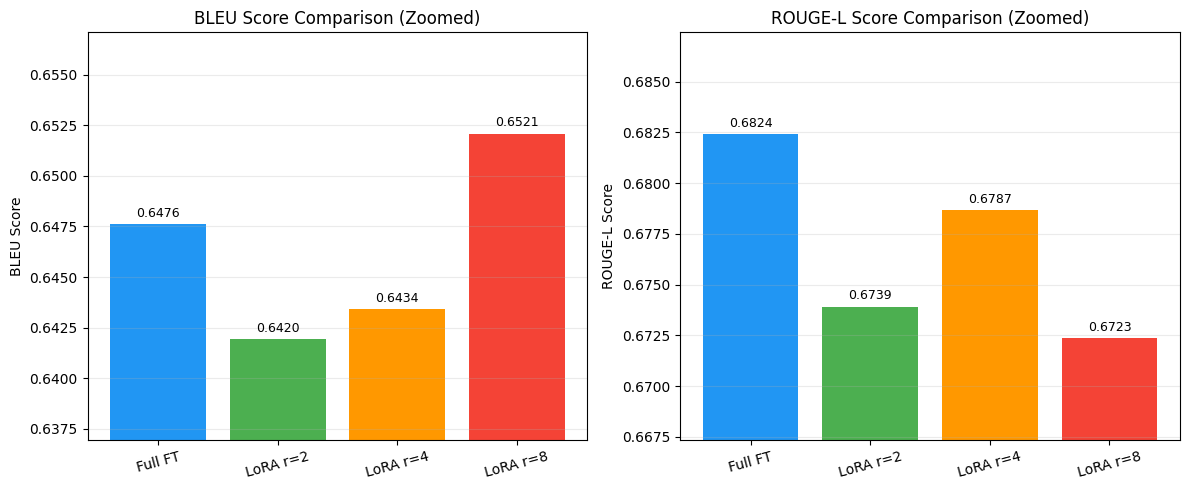

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names = [name for name, _ in all_results]
bleu_scores = [res["test_metrics"]["bleu"] for _, res in all_results]
rouge_scores = [res["test_metrics"]["rouge_l"] for _, res in all_results]

colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

def set_zoomed_axis(ax, scores):
    score_min = min(scores)
    score_max = max(scores)
    padding = max((score_max - score_min) * 0.35, 0.005)
    ax.set_ylim(score_min - padding, score_max + padding)
    ax.grid(axis="y", alpha=0.25)

bars = axes[0].bar(names, bleu_scores, color=colors)
axes[0].set_ylabel("BLEU Score")
axes[0].set_title("BLEU Score Comparison (Zoomed)")
axes[0].tick_params(axis="x", rotation=15)
set_zoomed_axis(axes[0], bleu_scores)
axes[0].bar_label(bars, fmt="%.4f", padding=3, fontsize=9)

bars = axes[1].bar(names, rouge_scores, color=colors)
axes[1].set_ylabel("ROUGE-L Score")
axes[1].set_title("ROUGE-L Score Comparison (Zoomed)")
axes[1].tick_params(axis="x", rotation=15)
set_zoomed_axis(axes[1], rouge_scores)
axes[1].bar_label(bars, fmt="%.4f", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "metrics_comparison.png", dpi=150)
plt.show()


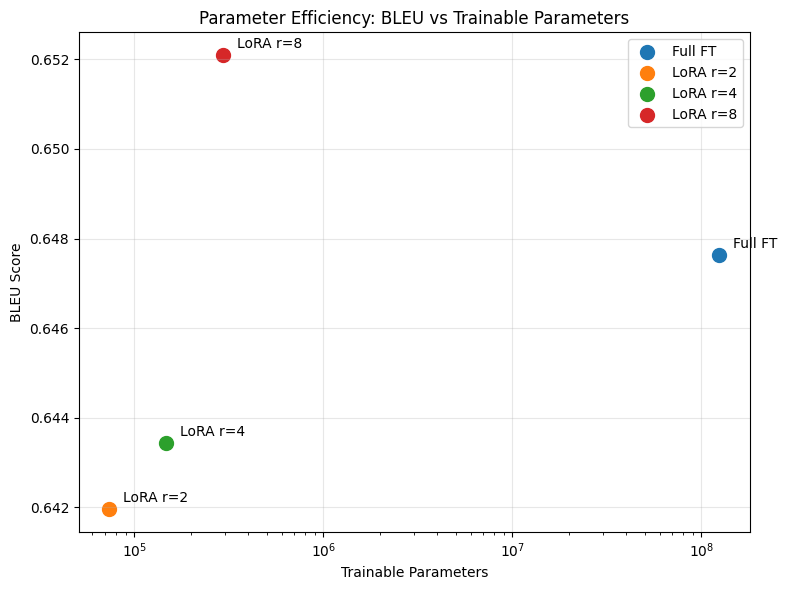

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in all_results:
    ax.scatter(
        res["params"]["trainable"],
        res["test_metrics"]["bleu"],
        s=100,
        label=name,
    )
    ax.annotate(name, (res["params"]["trainable"], res["test_metrics"]["bleu"]),
                textcoords="offset points", xytext=(10, 5))

ax.set_xlabel("Trainable Parameters")
ax.set_ylabel("BLEU Score")
ax.set_title("Parameter Efficiency: BLEU vs Trainable Parameters")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "param_efficiency.png", dpi=150)
plt.show()

In [13]:
# export result artifacts back through notebook output
import base64, io, pathlib, zipfile
bundle = PROJECT_ROOT / 'artifact_bundle.zip'
with zipfile.ZipFile(bundle, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path in (RESULTS_DIR).rglob('*'):
        if path.is_file():
            zf.write(path, path.relative_to(PROJECT_ROOT))
payload = base64.b64encode(bundle.read_bytes()).decode('ascii')
print('ARTIFACT_BUNDLE_BASE64_START')
print(payload)
print('ARTIFACT_BUNDLE_BASE64_END')


ARTIFACT_BUNDLE_BASE64_START
...
ARTIFACT_BUNDLE_BASE64_END
